# Human Activity Recognition

In [2]:
# skip this cell if you're not on colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Data

In [3]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


In [4]:
!unzip /content/drive/MyDrive/Data_Mining/HW3/data.zip

Streaming output truncated to the last 5000 lines.
  inflating: data/train/train/User_001/00034.csv  
  inflating: __MACOSX/data/train/train/User_001/._00034.csv  
  inflating: data/train/train/User_001/00020.csv  
  inflating: __MACOSX/data/train/train/User_001/._00020.csv  
  inflating: data/train/train/User_001/00036.csv  
  inflating: __MACOSX/data/train/train/User_001/._00036.csv  
  inflating: data/train/train/User_001/00022.csv  
  inflating: __MACOSX/data/train/train/User_001/._00022.csv  
  inflating: data/train/train/User_001/00181.csv  
  inflating: __MACOSX/data/train/train/User_001/._00181.csv  
  inflating: data/train/train/User_001/00195.csv  
  inflating: __MACOSX/data/train/train/User_001/._00195.csv  
  inflating: data/train/train/User_001/00142.csv  
  inflating: __MACOSX/data/train/train/User_001/._00142.csv  
  inflating: data/train/train/User_001/00156.csv  
  inflating: __MACOSX/data/train/train/User_001/._00156.csv  
  inflating: data/train/train/User_001/00157.

In [5]:
import catboost
import lightgbm
import numpy as np
import pandas as pd
import os

## Aggregate all training data and establish a baseline

In [ ]:
def load_all_training_data(data_dir):
    all_data = []
    train_dir = os.path.join(data_dir, 'train', 'train')
    user_dirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

    print(f"Found {len(user_dirs)} user directories.")

    for user_dir in user_dirs:
        user_path = os.path.join(train_dir, user_dir)
        csv_files = [f for f in os.listdir(user_path) if f.endswith('.csv')]
        for csv_file in csv_files:
            file_path = os.path.join(user_path, csv_file)
            df = pd.read_csv(file_path)
            # Add user_id and file_name if useful for later analysis
            df['user_id'] = user_dir
            df['original_file'] = csv_file
            all_data.append(df)

    combined_df = pd.concat(all_data, ignore_index=True)
    return combined_df


# Load all training data
full_train_df = load_all_training_data('/content/data')
print('\nCombined DataFrame head:')
display(full_train_df.head())
print('\nCombined DataFrame Info:')
full_train_df.info()
print('\nLabel distribution in full training data:')
display(full_train_df['label'].value_counts())

Found 60 user directories.

Combined DataFrame head:


,index,mean_x,mean_y,mean_z,std_x,std_y,std_z,label,file_id,user_id,original_file
0,0,-1.348095,-0.242441,-0.054912,1.843705,1.253630,0.444245,3,4884,User_027,04884.csv
1,1,-1.205061,-0.588606,-0.077975,1.931051,1.229279,0.433171,3,4884,User_027,04884.csv
2,2,-1.171201,0.070353,-0.173849,1.785977,1.420688,0.509423,3,4884,User_027,04884.csv
3,3,-1.114874,-0.569229,-0.233317,1.918999,1.267599,0.425316,3,4884,User_027,04884.csv
4,4,-1.407280,-0.417756,-0.173366,1.725858,1.260530,0.368921,3,4884,User_027,04884.csv



Combined DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306000 entries, 0 to 3305999
Data columns (total 11 columns):
 #   Column         Dtype  
---  ------         -----  
 0   index          int64  
 1   mean_x         float64
 2   mean_y         float64
 3   mean_z         float64
 4   std_x          float64
 5   std_y          float64
 6   std_z          float64
 7   label          int64  
 8   file_id        int64  
 9   user_id        object 
 10  original_file  object 
dtypes: float64(6), int64(3), object(2)
memory usage: 277.5+ MB

Label distribution in full training data:


,count
label,
1,1408500
0,1392900
3,196800
5,157800
2,107400
4,42600


The data is now aggregated. Let's establish a baseline using Logistic Regression.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# Define features (X) and target (y)
# Excluding 'index', 'user_id', 'original_file' as they are identifiers/metadata
features = ['mean_x', 'mean_y', 'mean_z', 'std_x', 'std_y', 'std_z']
X = full_train_df[features]
y = full_train_df['label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

# Train a Logistic Regression model
# Increased max_iter for convergence on potentially complex datasets
# Added solver='liblinear' which is good for small datasets and handles L1/L2 regularization
model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear', multi_class='ovr')
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using macro F1-score, consistent with previous NN outputs
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"\nLogistic Regression Baseline Macro F1-score: {f1_macro:.4f}")

Training set size: 2644800 samples
Testing set size: 661200 samples


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression Baseline Macro F1-score: 0.3023


## Exploratory Data Analysis (EDA)
We will now visualize the class distribution and feature characteristics.

/tmp/ipykernel_2443/2559054882.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


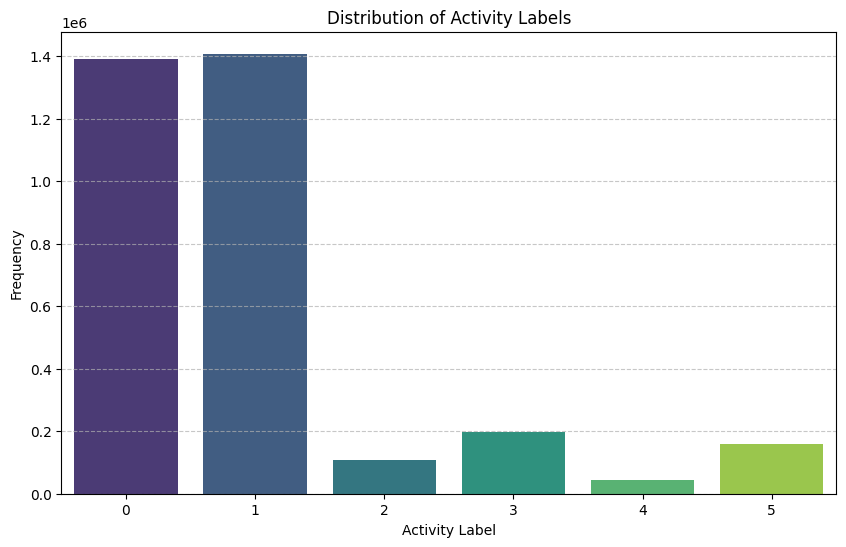

Label Percentages:
label
0    42.132486
1    42.604356
2     3.248639
3     5.952813
4     1.288566
5     4.773140
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Class Distribution Analysis
plt.figure(figsize=(10, 6))
label_counts = full_train_df['label'].value_counts().sort_index()
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution of Activity Labels')
plt.xlabel('Activity Label')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print percentages for precise observation of imbalance
print("Label Percentages:")
print(full_train_df['label'].value_counts(normalize=True).sort_index() * 100)

/tmp/ipykernel_2443/1500386451.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='label', y=col, data=full_train_df.sample(n=100000, random_state=42), palette='Set2')
/tmp/ipykernel_2443/1500386451.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='label', y=col, data=full_train_df.sample(n=100000, random_state=42), palette='Set2')
/tmp/ipykernel_2443/1500386451.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='label', y=col, data=full_train_df.sample(n=100000, random_state=42), palette='Set2'

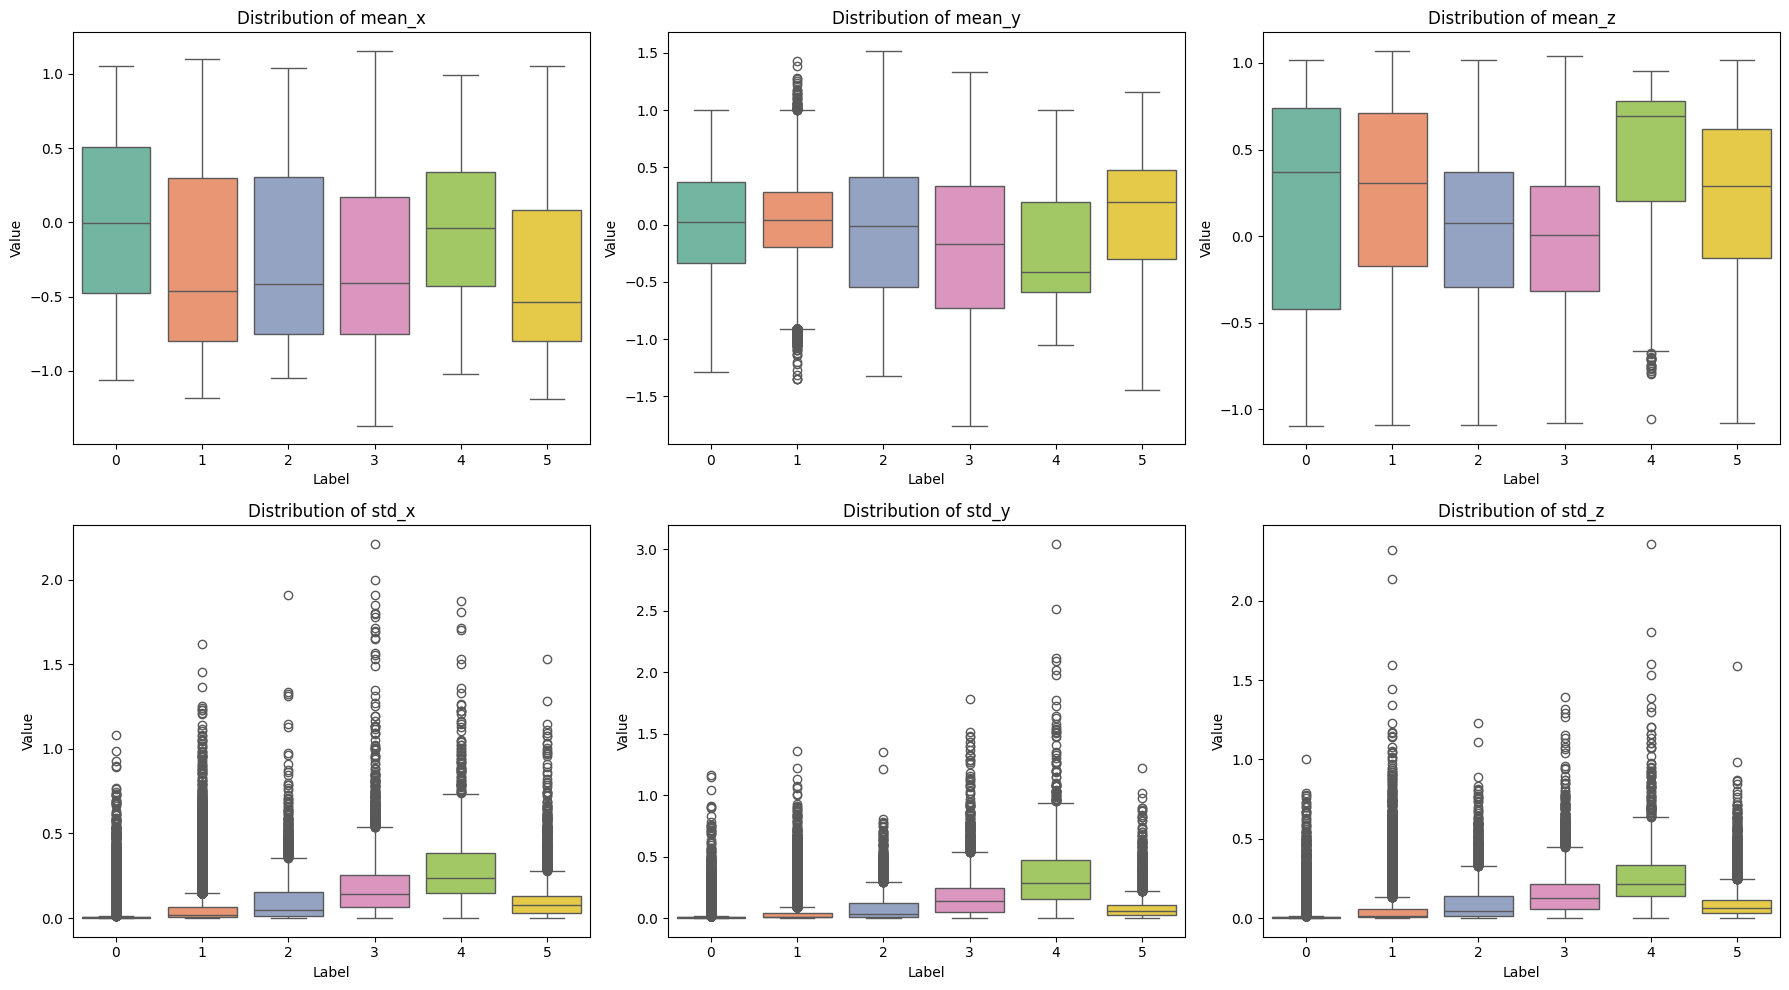

In [ ]:
# 2. Feature Distribution across Labels
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(ax=axes[i], x='label', y=col, data=full_train_df.sample(n=100000, random_state=42), palette='Set2')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Label')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

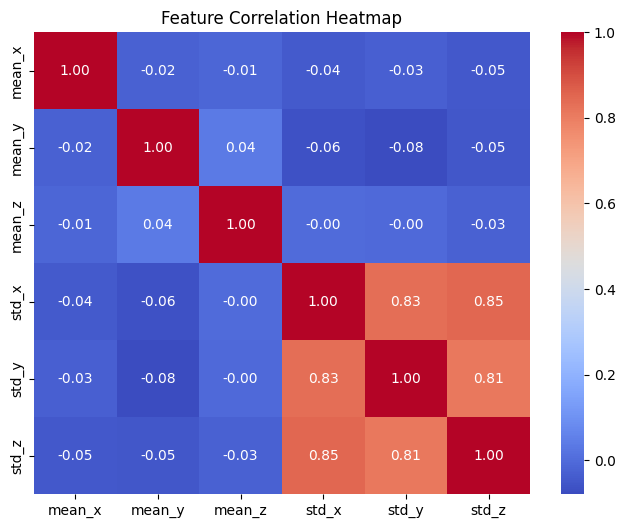

In [ ]:
# 3. Correlation Heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = full_train_df[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## Train

### LGBM

#### Best

In [7]:
%%bash
REPO=/content/drive/MyDrive/Data_Mining/HW3
DATA=/content/data
CACHE="$REPO/artifacts/cache_lgb"

python "$REPO/train_lgb.py" \
  --data-dir "$DATA" \
  --cache-dir "$CACHE" \
  --output-probs "$REPO/artifacts/lgb.npy"

Loading cache...
Feature config: {'include_magnitude': True, 'include_base_stats': True, 'include_diff_stats': True, 'include_spectral': True, 'include_autocorr': True, 'include_chunk': True, 'include_correlations': True, 'include_advanced_interactions': False}
Handcrafted feature dimension: 674
Training LightGBM with seed 42...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.143392 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 170745
[LightGBM] [Info] Number of data points in the train set: 8810, number of used features: 674
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive g

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

#### Preprocessing ablations (test with 2-folds)

In [ ]:
%%bash
REPO=/content/drive/MyDrive/Data_Mining/HW3
DATA=/content/data
CACHE="$REPO/artifacts/cache_lgb_ablation"

python "$REPO/train_lgb.py" --data-dir "$DATA" --cache-dir "$CACHE" --max-folds 2 --n-estimators 150 --skip-test-preds --seed 42 --disable-magnitude
python "$REPO/train_lgb.py" --data-dir "$DATA" --cache-dir "$CACHE" --max-folds 2 --n-estimators 150 --skip-test-preds --seed 42 --disable-diff-stats
python "$REPO/train_lgb.py" --data-dir "$DATA" --cache-dir "$CACHE" --max-folds 2 --n-estimators 150 --skip-test-preds --seed 42 --disable-spectral
python "$REPO/train_lgb.py" --data-dir "$DATA" --cache-dir "$CACHE" --max-folds 2 --n-estimators 150 --skip-test-preds --seed 42 --disable-autocorr
python "$REPO/train_lgb.py" --data-dir "$DATA" --cache-dir "$CACHE" --max-folds 2 --n-estimators 150 --skip-test-preds --seed 42 --disable-chunk
python "$REPO/train_lgb.py" --data-dir "$DATA" --cache-dir "$CACHE" --max-folds 2 --n-estimators 150 --skip-test-preds --seed 42 --disable-correlations
python "$REPO/train_lgb.py" --data-dir "$DATA" --cache-dir "$CACHE" --max-folds 2 --n-estimators 150 --skip-test-preds --seed 42 --class-balance none

Loading cache...
Feature config: {'include_magnitude': False, 'include_base_stats': True, 'include_diff_stats': True, 'include_spectral': True, 'include_autocorr': True, 'include_chunk': True, 'include_correlations': True, 'include_advanced_interactions': False}
Handcrafted feature dimension: 507
Training LightGBM with seed 42...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.119605 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 128411
[LightGBM] [Info] Number of data points in the train set: 8810, number of used features: 507
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

### NN

In [ ]:
!python /content/drive/MyDrive/Data_Mining/HW3/train.py --data-dir /content/data --epochs 20 --folds 5 --batch-size 128 --workers 2 --output-dir /content/drive/MyDrive/Data_Mining/HW3/artifacts/checkpoints_v2/seed42 --seed 42

Using device: cuda
Training samples: 11020
Label distribution: {0: 4643, 1: 4695, 2: 358, 3: 656, 4: 142, 5: 526}

Fold 1/5
Epoch 01 | train_loss=0.6089 train_f1=0.5603 | val_loss=1.4813 val_f1=0.4367
Epoch 02 | train_loss=0.3987 train_f1=0.7000 | val_loss=1.3784 val_f1=0.5198
Epoch 03 | train_loss=0.3217 train_f1=0.7501 | val_loss=1.3279 val_f1=0.5260
Epoch 04 | train_loss=0.2839 train_f1=0.7936 | val_loss=1.4241 val_f1=0.5376
Epoch 05 | train_loss=0.2427 train_f1=0.8284 | val_loss=1.3826 val_f1=0.5506
Epoch 06 | train_loss=0.2086 train_f1=0.8499 | val_loss=1.4248 val_f1=0.5430
Epoch 07 | train_loss=0.1823 train_f1=0.8652 | val_loss=1.4716 val_f1=0.5493
Epoch 08 | train_loss=0.1626 train_f1=0.8852 | val_loss=1.3960 val_f1=0.5859
Epoch 09 | train_loss=0.1489 train_f1=0.8946 | val_loss=1.3832 val_f1=0.6041
Epoch 10 | train_loss=0.1345 train_f1=0.9162 | val_loss=1.3988 val_f1=0.5912
Epoch 11 | train_loss=0.1314 train_f1=0.9219 | val_loss=1.3638 val_f1=0.6088
Epoch 12 | train_loss=0.1244 

In [ ]:
!python /content/drive/MyDrive/Data_Mining/HW3/train.py --data-dir /content/data --epochs 20 --folds 5 --batch-size 128 --workers 2 --output-dir /content/drive/MyDrive/Data_Mining/HW3/artifacts/checkpoints_v2/seed52 --seed 52

Using device: cuda
Training samples: 11020
Label distribution: {0: 4643, 1: 4695, 2: 358, 3: 656, 4: 142, 5: 526}

Fold 1/5
Epoch 01 | train_loss=0.5994 train_f1=0.5523 | val_loss=1.3034 val_f1=0.4940
Epoch 02 | train_loss=0.3907 train_f1=0.7002 | val_loss=1.2742 val_f1=0.5527
Epoch 03 | train_loss=0.3285 train_f1=0.7543 | val_loss=1.3313 val_f1=0.5223
Epoch 04 | train_loss=0.2929 train_f1=0.7814 | val_loss=1.4649 val_f1=0.4884
Epoch 05 | train_loss=0.2476 train_f1=0.8134 | val_loss=1.3071 val_f1=0.5845
Epoch 06 | train_loss=0.2082 train_f1=0.8535 | val_loss=1.3399 val_f1=0.5822
Epoch 07 | train_loss=0.1771 train_f1=0.8773 | val_loss=1.5395 val_f1=0.5131
Epoch 08 | train_loss=0.1638 train_f1=0.8870 | val_loss=1.4089 val_f1=0.5886
Epoch 09 | train_loss=0.1464 train_f1=0.9022 | val_loss=1.3903 val_f1=0.6059
Epoch 10 | train_loss=0.1384 train_f1=0.9084 | val_loss=1.4144 val_f1=0.6245
Epoch 11 | train_loss=0.1247 train_f1=0.9234 | val_loss=1.4516 val_f1=0.5814
Epoch 12 | train_loss=0.1258 

In [ ]:
!python /content/drive/MyDrive/Data_Mining/HW3/train.py --data-dir /content/data --epochs 20 --folds 5 --batch-size 128 --workers 2 --output-dir /content/drive/MyDrive/Data_Mining/HW3/artifacts/checkpoints_v2/seed62 --seed 62

Using device: cuda
Training samples: 11020
Label distribution: {0: 4643, 1: 4695, 2: 358, 3: 656, 4: 142, 5: 526}

Fold 1/5
Epoch 01 | train_loss=0.6020 train_f1=0.5562 | val_loss=1.3302 val_f1=0.4679
Epoch 02 | train_loss=0.3890 train_f1=0.7075 | val_loss=1.2978 val_f1=0.5318
Epoch 03 | train_loss=0.3344 train_f1=0.7511 | val_loss=1.4056 val_f1=0.5028
Epoch 04 | train_loss=0.2888 train_f1=0.8037 | val_loss=1.3794 val_f1=0.5435
Epoch 05 | train_loss=0.2511 train_f1=0.8268 | val_loss=1.3454 val_f1=0.5371
Epoch 06 | train_loss=0.2200 train_f1=0.8519 | val_loss=1.4355 val_f1=0.5568
Epoch 07 | train_loss=0.1977 train_f1=0.8625 | val_loss=1.4666 val_f1=0.5636
Epoch 08 | train_loss=0.1669 train_f1=0.8842 | val_loss=1.4613 val_f1=0.5592
Epoch 09 | train_loss=0.1477 train_f1=0.8989 | val_loss=1.4073 val_f1=0.5945
Epoch 10 | train_loss=0.1343 train_f1=0.9122 | val_loss=1.3898 val_f1=0.6049
Epoch 11 | train_loss=0.1366 train_f1=0.9155 | val_loss=1.2955 val_f1=0.6169
Epoch 12 | train_loss=0.1286 

In [ ]:
!python /content/drive/MyDrive/Data_Mining/HW3/train.py --data-dir /content/data --epochs 20 --folds 5 --batch-size 128 --workers 2 --output-dir /content/drive/MyDrive/Data_Mining/HW3/artifacts/checkpoints_v2/seed72 --seed 72

Using device: cuda
Training samples: 11020
Label distribution: {0: 4643, 1: 4695, 2: 358, 3: 656, 4: 142, 5: 526}

Fold 1/5
Epoch 01 | train_loss=0.6215 train_f1=0.5480 | val_loss=1.4822 val_f1=0.4783
Epoch 02 | train_loss=0.4102 train_f1=0.7137 | val_loss=1.3516 val_f1=0.5020
Epoch 03 | train_loss=0.3448 train_f1=0.7551 | val_loss=1.3584 val_f1=0.5398
Epoch 04 | train_loss=0.2837 train_f1=0.7914 | val_loss=1.3307 val_f1=0.5312
Epoch 05 | train_loss=0.2307 train_f1=0.8417 | val_loss=1.4457 val_f1=0.5361
Epoch 06 | train_loss=0.2083 train_f1=0.8561 | val_loss=1.3950 val_f1=0.5697
Epoch 07 | train_loss=0.1887 train_f1=0.8753 | val_loss=1.4259 val_f1=0.5366
Epoch 08 | train_loss=0.1721 train_f1=0.8797 | val_loss=1.3398 val_f1=0.5880
Epoch 09 | train_loss=0.1467 train_f1=0.8986 | val_loss=1.4275 val_f1=0.5736
Epoch 10 | train_loss=0.1378 train_f1=0.9134 | val_loss=1.4396 val_f1=0.5828
Epoch 11 | train_loss=0.1290 train_f1=0.9191 | val_loss=1.3371 val_f1=0.6080
Epoch 12 | train_loss=0.1251 

In [ ]:
!python /content/drive/MyDrive/Data_Mining/HW3/train.py --data-dir /content/data --epochs 20 --folds 5 --batch-size 128 --workers 2 --output-dir /content/drive/MyDrive/Data_Mining/HW3/artifacts/checkpoints_v2/seed82 --seed 82

Using device: cuda
Training samples: 11020
Label distribution: {0: 4643, 1: 4695, 2: 358, 3: 656, 4: 142, 5: 526}

Fold 1/5
Epoch 01 | train_loss=0.6384 train_f1=0.5383 | val_loss=1.3551 val_f1=0.4663
Epoch 02 | train_loss=0.4173 train_f1=0.6949 | val_loss=1.3300 val_f1=0.4985
Epoch 03 | train_loss=0.3343 train_f1=0.7707 | val_loss=1.3933 val_f1=0.5349
Epoch 04 | train_loss=0.2880 train_f1=0.8003 | val_loss=1.4140 val_f1=0.4942
Epoch 05 | train_loss=0.2477 train_f1=0.8197 | val_loss=1.3977 val_f1=0.5171
Epoch 06 | train_loss=0.2113 train_f1=0.8478 | val_loss=1.4373 val_f1=0.5262
Epoch 07 | train_loss=0.1944 train_f1=0.8562 | val_loss=1.4029 val_f1=0.5713
Epoch 08 | train_loss=0.1689 train_f1=0.8840 | val_loss=1.4263 val_f1=0.5485
Epoch 09 | train_loss=0.1616 train_f1=0.8900 | val_loss=1.3842 val_f1=0.5766
Epoch 10 | train_loss=0.1396 train_f1=0.9033 | val_loss=1.3620 val_f1=0.5757
Epoch 11 | train_loss=0.1329 train_f1=0.9191 | val_loss=1.2901 val_f1=0.6190
Epoch 12 | train_loss=0.1284 

#### 3-seeds 5-fold
LB: 0.7365

In [ ]:
!python /content/drive/MyDrive/Data_Mining/HW3/predict.py --data-dir /content/data --checkpoint-dir /content/drive/MyDrive/Data_Mining/HW3/artifacts/checkpoints_v2 --output /content/drive/MyDrive/Data_Mining/HW3/artifacts/submission_v2.csv

Found 25 checkpoint(s) under /content/drive/MyDrive/Data_Mining/HW3/artifacts/checkpoints_v2
Checkpoint summary:
- seed42: 5 checkpoint(s) [fold_0, fold_1, fold_2, fold_3, fold_4]
- seed52: 5 checkpoint(s) [fold_0, fold_1, fold_2, fold_3, fold_4]
- seed62: 5 checkpoint(s) [fold_0, fold_1, fold_2, fold_3, fold_4]
- seed72: 5 checkpoint(s) [fold_0, fold_1, fold_2, fold_3, fold_4]
- seed82: 5 checkpoint(s) [fold_0, fold_1, fold_2, fold_3, fold_4]
Loaded seed42/fold_0.pt
Loaded seed42/fold_1.pt
Loaded seed42/fold_2.pt
Loaded seed42/fold_3.pt
Loaded seed42/fold_4.pt
Loaded seed52/fold_0.pt
Loaded seed52/fold_1.pt
Loaded seed52/fold_2.pt
Loaded seed52/fold_3.pt
Loaded seed52/fold_4.pt
Loaded seed62/fold_0.pt
Loaded seed62/fold_1.pt
Loaded seed62/fold_2.pt
Loaded seed62/fold_3.pt
Loaded seed62/fold_4.pt
Loaded seed72/fold_0.pt
Loaded seed72/fold_1.pt
Loaded seed72/fold_2.pt
Loaded seed72/fold_3.pt
Loaded seed72/fold_4.pt
Loaded seed82/fold_0.pt
Loaded seed82/fold_1.pt
Loaded seed82/fold_2.pt


#### 5-seeds 5-fold
LB: 0.7365 (no improvement)

In [ ]:
!python /content/drive/MyDrive/Data_Mining/HW3/predict.py --checkpoint-dir /content/drive/MyDrive/Data_Mining/HW3/artifacts/checkpoints_v2 --summary-only --expected-checkpoints 25
!python /content/drive/MyDrive/Data_Mining/HW3/predict.py --data-dir /content/data --checkpoint-dir /content/drive/MyDrive/Data_Mining/HW3/artifacts/checkpoints_v2 --expected-checkpoints 25 --output /content/drive/MyDrive/Data_Mining/HW3/artifacts/submission_v2.csv


Found 25 checkpoint(s) under /content/drive/MyDrive/Data_Mining/HW3/artifacts/checkpoints_v2
Checkpoint summary:
- seed42: 5 checkpoint(s) [fold_0, fold_1, fold_2, fold_3, fold_4]
- seed52: 5 checkpoint(s) [fold_0, fold_1, fold_2, fold_3, fold_4]
- seed62: 5 checkpoint(s) [fold_0, fold_1, fold_2, fold_3, fold_4]
- seed72: 5 checkpoint(s) [fold_0, fold_1, fold_2, fold_3, fold_4]
- seed82: 5 checkpoint(s) [fold_0, fold_1, fold_2, fold_3, fold_4]
Found 25 checkpoint(s) under /content/drive/MyDrive/Data_Mining/HW3/artifacts/checkpoints_v2
Checkpoint summary:
- seed42: 5 checkpoint(s) [fold_0, fold_1, fold_2, fold_3, fold_4]
- seed52: 5 checkpoint(s) [fold_0, fold_1, fold_2, fold_3, fold_4]
- seed62: 5 checkpoint(s) [fold_0, fold_1, fold_2, fold_3, fold_4]
- seed72: 5 checkpoint(s) [fold_0, fold_1, fold_2, fold_3, fold_4]
- seed82: 5 checkpoint(s) [fold_0, fold_1, fold_2, fold_3, fold_4]
Loaded seed42/fold_0.pt
Loaded seed42/fold_1.pt
Loaded seed42/fold_2.pt
Loaded seed42/fold_3.pt
Loaded s

### Multiseeds LGBM Training

In [ ]:
%%bash
REPO=/content/drive/MyDrive/Data_Mining/HW3
DATA=/content/data
CACHE="$REPO/artifacts/cache_lgb_ablation"

python "$REPO/train_lgb.py" \
  --data-dir "$DATA" \
  --cache-dir "$CACHE" \
  --seed 42 \
  --output-probs "$REPO/artifacts/lgb_seed_42.npy"

Loading cache...
Feature config: {'include_magnitude': True, 'include_base_stats': True, 'include_diff_stats': True, 'include_spectral': True, 'include_autocorr': True, 'include_chunk': True, 'include_correlations': True, 'include_advanced_interactions': False}
Handcrafted feature dimension: 674
Training LightGBM with seed 42...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.144662 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 170745
[LightGBM] [Info] Number of data points in the train set: 8810, number of used features: 674
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive g

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
%%bash
REPO=/content/drive/MyDrive/Data_Mining/HW3
DATA=/content/data
CACHE="$REPO/artifacts/cache_lgb_ablation"

python "$REPO/train_lgb.py" \
  --data-dir "$DATA" \
  --cache-dir "$CACHE" \
  --seed 52 \
  --output-probs "$REPO/artifacts/lgb_seed_52.npy"

Loading cache...
Feature config: {'include_magnitude': True, 'include_base_stats': True, 'include_diff_stats': True, 'include_spectral': True, 'include_autocorr': True, 'include_chunk': True, 'include_correlations': True, 'include_advanced_interactions': False}
Handcrafted feature dimension: 674
Training LightGBM with seed 52...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.147540 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 170745
[LightGBM] [Info] Number of data points in the train set: 8810, number of used features: 674
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive g

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
%%bash
REPO=/content/drive/MyDrive/Data_Mining/HW3
DATA=/content/data
CACHE="$REPO/artifacts/cache_lgb_ablation"

python "$REPO/train_lgb.py" \
  --data-dir "$DATA" \
  --cache-dir "$CACHE" \
  --seed 62 \
  --output-probs "$REPO/artifacts/lgb_seed_62.npy"

Loading cache...
Feature config: {'include_magnitude': True, 'include_base_stats': True, 'include_diff_stats': True, 'include_spectral': True, 'include_autocorr': True, 'include_chunk': True, 'include_correlations': True, 'include_advanced_interactions': False}
Handcrafted feature dimension: 674
Training LightGBM with seed 62...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.135256 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 170745
[LightGBM] [Info] Number of data points in the train set: 8810, number of used features: 674
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive g

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
import numpy as np

paths = [
    "/content/drive/MyDrive/Data_Mining/HW3/artifacts/lgb_seed_42.npy",
    "/content/drive/MyDrive/Data_Mining/HW3/artifacts/lgb_seed_52.npy",
    "/content/drive/MyDrive/Data_Mining/HW3/artifacts/lgb_seed_62.npy",
]

probs = np.mean([np.load(p) for p in paths], axis=0)
out_path = "/content/drive/MyDrive/Data_Mining/HW3/artifacts/lgb_multiseed_3.npy"
np.save(out_path, probs)
print("saved to", out_path, probs.shape)

saved to /content/drive/MyDrive/Data_Mining/HW3/artifacts/lgb_multiseed_3.npy (6849, 6)


### Class weight boost (test with 2-folds)

In [ ]:
%%bash
REPO=/content/drive/MyDrive/Data_Mining/HW3
DATA=/content/data
CACHE="$REPO/artifacts/cache_lgb_weight_tune"

python "$REPO/train_lgb.py" \
  --data-dir "$DATA" \
  --cache-dir "$CACHE" \
  --max-folds 2 \
  --n-estimators 150 \
  --skip-test-preds \
  --seed 42 \
  --class-weight-boost "2:1.15,4:1.60,5:1.25"

Loading cache...
Feature config: {'include_magnitude': True, 'include_base_stats': True, 'include_diff_stats': True, 'include_spectral': True, 'include_autocorr': True, 'include_chunk': True, 'include_correlations': True, 'include_advanced_interactions': False}
Handcrafted feature dimension: 674
Training LightGBM with seed 42...
Fold 0 class_weight: {0: 0.3912425637245178, 1: 0.3965253531932831, 2: 5.842848777770995, 3: 2.7548468112945557, 4: 20.25287322998047, 5: 4.412059187889099}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.169110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 170745
[LightGBM] [Info] Number of data points in the train set: 8810, number of used features: 674
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.806148
[LightGBM] [Info] Start training from score -1.945910
[Ligh

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
%%bash
REPO=/content/drive/MyDrive/Data_Mining/HW3
DATA=/content/data
CACHE="$REPO/artifacts/cache_lgb_weight_tune"

python "$REPO/train_lgb.py" \
  --data-dir "$DATA" \
  --cache-dir "$CACHE" \
  --class-weight-boost "2:1.10,4:1.25,5:1.10" \
  --output-probs "$REPO/artifacts/lgb_weight_tuned.npy"

Process is terminated.


### CatBoost

In [ ]:
%%bash
REPO=/content/drive/MyDrive/Data_Mining/HW3
DATA=/content/data
CACHE="$REPO/artifacts/cache_catboost"

python "/$REPO/train_catboost.py" \
  --data-dir "$DATA" \
  --cache-dir "$CACHE" \
  --iterations 500 \
  --seed 42 \
  --output-probs "/$REPO/artifacts/catboost_test_probs.npy"

Loading cache...
Feature config: {'include_magnitude': True, 'include_base_stats': True, 'include_diff_stats': True, 'include_spectral': True, 'include_autocorr': True, 'include_chunk': True, 'include_correlations': True, 'include_advanced_interactions': False}
Handcrafted feature dimension: 674
Training CatBoost with seed 42...
Fold 0 class_weights: [0.3912425637245178, 0.3965253531932831, 5.080738067626953, 2.7548468112945557, 12.658045768737793, 3.5296473503112793]
Fold 0 completed. Validation macro F1-score: 0.6667
Fold 1 class_weights: [0.39332619309425354, 0.3961932957172394, 5.1132402420043945, 2.779356002807617, 13.587963104248047, 3.2829978466033936]
Fold 1 completed. Validation macro F1-score: 0.6694
Fold 2 class_weights: [0.3937366306781769, 0.3875131607055664, 5.272401332855225, 2.8563106060028076, 13.372727394104004, 3.7717947959899902]
Fold 2 completed. Validation macro F1-score: 0.6844
Fold 3 class_weights: [0.40225017070770264, 0.38269197940826416, 5.21926736831665, 2.8

## Predict and Output

### Best LGBM
LB(lgbm): 0.7853

OOF macro F1-score: 0.7261

In [8]:
%%bash
REPO=/content/drive/MyDrive/Data_Mining/HW3
DATA=/content/data

python "$REPO/predict_ensemble.py" \
  --data-dir "$DATA" \
  --nn-weight 0 \
  --lgb-probs "$REPO/artifacts/lgb.npy" \
  --output "$REPO/artifacts/submission_lgb.csv"

Blending models (NN weight: 0.00, LightGBM weight: 1.00)...
Ensemble submission successfully saved to /content/drive/MyDrive/Data_Mining/HW3/artifacts/submission_lgb_baseline.csv


### Ensemble: 0.4 LightGBM + 0.6 V2_hybrid
LB(custom_ensemble.csv): 0.7388

In [ ]:
!python /content/drive/MyDrive/Data_Mining/HW3/predict_ensemble.py --nn-weight 0.6 --nn-logits "/content/drive/MyDrive/Data_Mining/HW3/artifacts/nn_logits.npy" --lgb-probs "/content/drive/MyDrive/Data_Mining/HW3/artifacts/lgb_test_probs.npy" --output "/content/drive/MyDrive/Data_Mining/HW3/artifacts/custom_ensemble.csv"

Loading predictions...
Blending models (NN weight: 0.60, LightGBM weight: 0.40)...
Ensemble submission successfully saved to /content/drive/MyDrive/Data_Mining/HW3/artifacts/custom_ensemble.csv


### Ensemble: 0.6 LightGBM + 0.4 V2_hybrid
LB(ensemble_submission.csv): 0.7832

In [ ]:
!python /content/drive/MyDrive/Data_Mining/HW3/predict_ensemble.py --nn-weight 0.4 --nn-logits "/content/drive/MyDrive/Data_Mining/HW3/artifacts/nn_logits.npy" --lgb-probs "/content/drive/MyDrive/Data_Mining/HW3/artifacts/lgb_test_probs.npy" --output "/content/drive/MyDrive/Data_Mining/HW3/artifacts/essemble_submission.csv"

Loading predictions...
Blending models (NN weight: 0.40, LightGBM weight: 0.60)...
Ensemble submission successfully saved to /content/drive/MyDrive/Data_Mining/HW3/artifacts/essemble_submission.csv


### Multiseeds LGBM

LB: 0.7853

In [ ]:
%%bash
REPO=/content/drive/MyDrive/Data_Mining/HW3
DATA=/content/data

python "$REPO/predict_ensemble.py" \
  --data-dir "$DATA" \
  --nn-weight 0 \
  --lgb-probs "$REPO/artifacts/lgb_multiseed_3.npy" \
  --output "$REPO/artifacts/submission_lgb_multiseed_3.csv"

Blending models (NN weight: 0.00, LightGBM weight: 1.00)...
Ensemble submission successfully saved to /content/drive/MyDrive/Data_Mining/HW3/artifacts/submission_lgb_multiseed_3.csv


### LGBM(0.7)+CatBoost(0.3)
LB: 0.7783

In [ ]:
%%bash
REPO=/content/drive/MyDrive/Data_Mining/HW3
DATA=/content/data

python "$REPO/predict_v2.py" \
  --data-dir "$DATA" \
  --lgb-probs "$REPO/artifacts/lgb_test_probs.npy" \
  --cat-probs "$REPO/artifacts/catboost_test_probs.npy" \
  --lgb-weight 0.7 \
  --output "$REPO/artifacts/submission_lgb_cat_07.csv"

Blending models (LightGBM weight: 0.70, CatBoost weight: 0.30)...
Ensemble submission successfully saved to /content/drive/MyDrive/Data_Mining/HW3/artifacts/submission_lgb_cat_07.csv


### LGBM(0.95)+CatBoost(0.05)
LB: 0.7853


In [ ]:
%%bash
REPO=/content/drive/MyDrive/Data_Mining/HW3
DATA=/content/data

python "$REPO/predict_v2.py" \
  --data-dir "$DATA" \
  --lgb-probs "$REPO/artifacts/lgb_test_probs.npy" \
  --cat-probs "$REPO/artifacts/catboost_test_probs.npy" \
  --lgb-weight 0.95 \
  --output "$REPO/artifacts/submission_lgb_cat_095.csv"

Blending models (LightGBM weight: 0.95, CatBoost weight: 0.05)...
Ensemble submission successfully saved to /content/drive/MyDrive/Data_Mining/HW3/artifacts/submission_lgb_cat_095.csv
